# Telco Customer Churn Analysis
## Data Analytics and Reporting (DAR) – Modular Assignment 3
### Module 3: Exploratory Data Analysis (EDA), Models and Techniques
#### Duration: 4 hours
##### Date: 22nd October 2025

In [379]:
# Basic Libraries

# Data handling
import pandas as pd
import numpy as np
import sys
import subprocess
def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import os, math, json, datetime, warnings
warnings.filterwarnings('ignore')
RSEED = 42

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
%matplotlib inline
# Use a valid matplotlib style - 'seaborn-v0_8' is the updated name for the seaborn style
# Alternatively, you could use 'seaborn-whitegrid', 'seaborn-darkgrid', etc.
plt.style.use('seaborn-v0_8')  # or simply remove this line if you don't need a specific style

# Stats
from scipy import stats
from scipy.stats import zscore, boxcox, skew
from scipy.stats.mstats import winsorize
from statsmodels.tsa.seasonal import seasonal_decompose

# Machine Learning
from sklearn.model_selection import cross_validate
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
                             mean_squared_error, r2_score, confusion_matrix, classification_report,
                             mean_absolute_percentage_error)
# Optional advanced models
import xgboost as xgb
import lightgbm as lgb

In [210]:
Data_Path = r"C:\Users\afrak\OneDrive\Desktop\WA_Fn-UseC_-Telco-Customer-Churn.csv"


In [211]:
df = pd.read_csv(Data_Path)

In [212]:
df.shape

(7043, 21)

In [213]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [214]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [215]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [216]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [217]:
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [218]:
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].str.strip()


In [219]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

#### Basic Data Understanding & Target Distribution

In [220]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [221]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [222]:
if 'Churn' in df.columns:
    df['Churn'].value_counts()
    df['Churn'].value_counts(normalize = True)
else:
    raise ValueError("Target 'Churn' not found in dataset")


In [223]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Part A: Advanced Exploratory Data Analysis (EDA)


Univariate & Bivariate Visualizations:

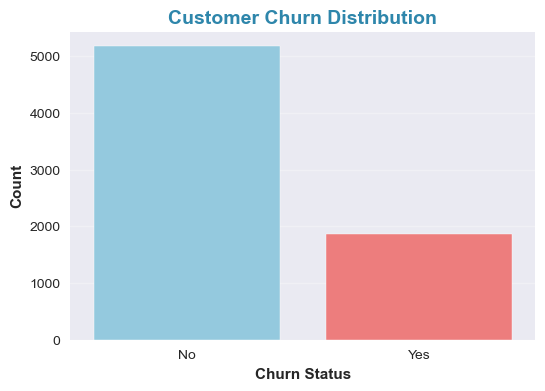

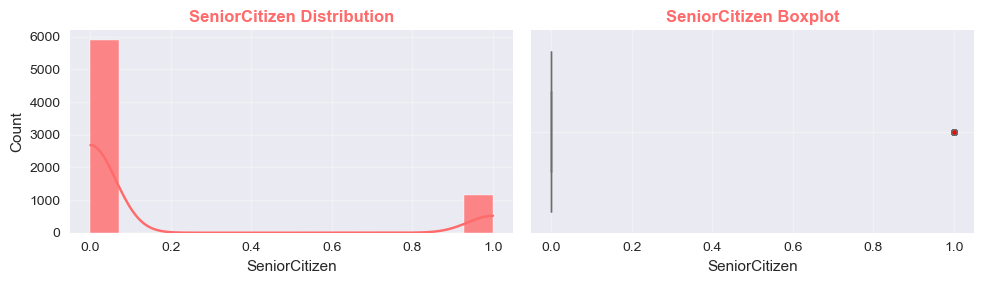

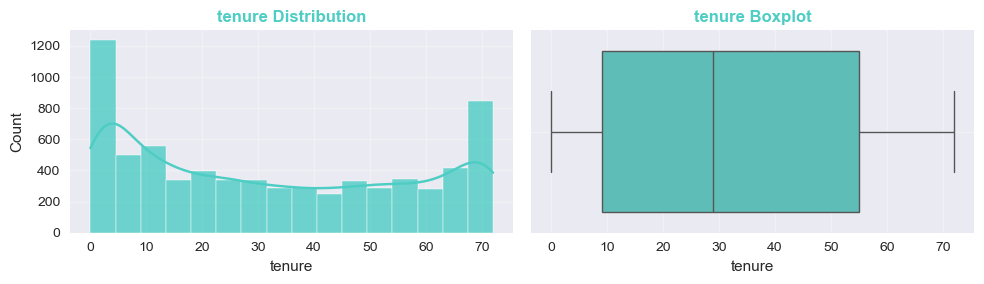

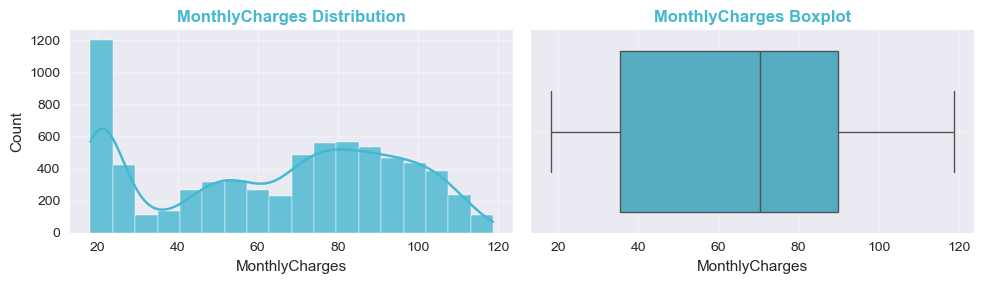

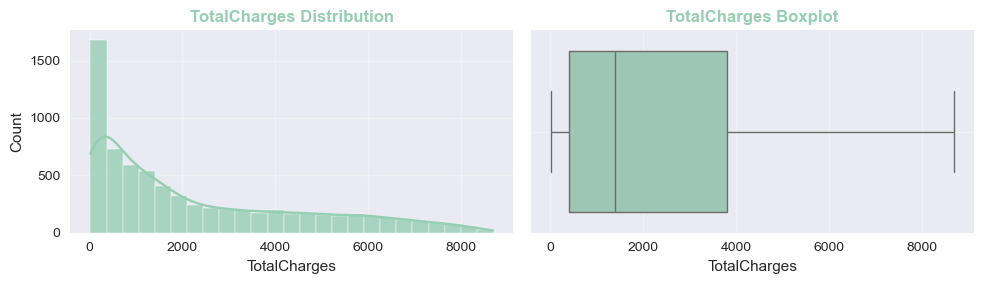

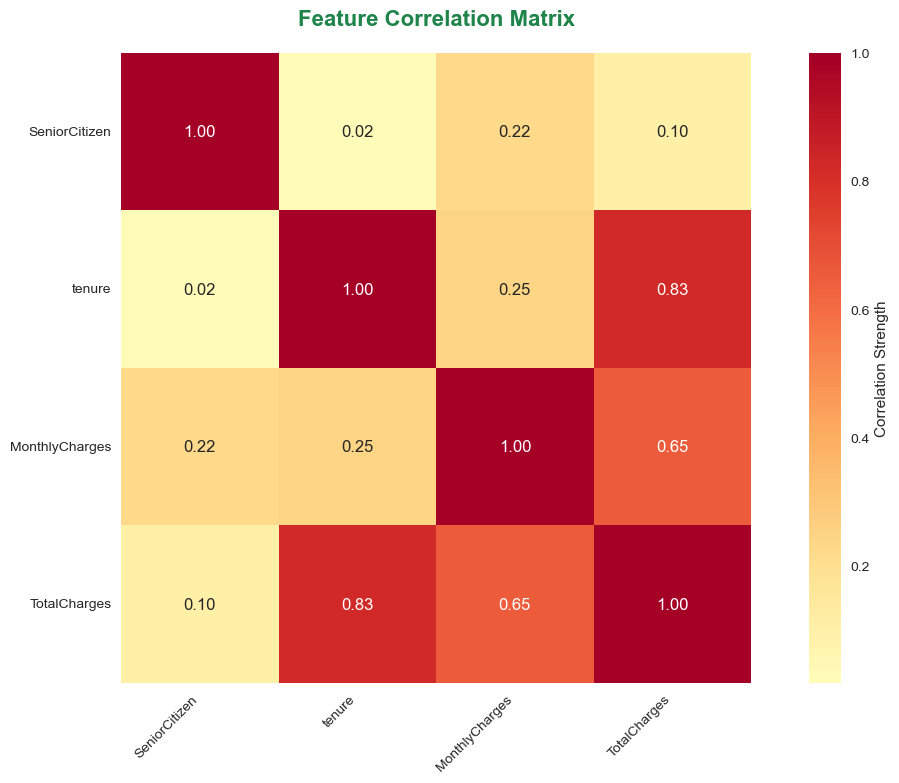

In [224]:
# 1. Target countplot
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette=['#87CEEB', '#FF6B6B'])
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold', color='#2E86AB')
plt.xlabel('Churn Status', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Numeric distributions 
numeric = df.select_dtypes(include=['int64','float64']).columns.tolist()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE']

for i, col in enumerate(numeric):
    color = colors[i % len(colors)]  # Cycle through colors if more than 9 variables
    
    plt.figure(figsize=(10,3))
    
    # Left subplot 
    plt.subplot(1,2,1)
    sns.histplot(df[col].dropna(), kde=True, 
                 color=color, edgecolor='white', alpha=0.8)
    plt.title(f'{col} Distribution', fontweight='bold', color=color)
    plt.grid(alpha=0.3)
    
    # Right subplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col], color=color, flierprops=dict(markerfacecolor='red', markersize=4))
    plt.title(f'{col} Boxplot', fontweight='bold', color=color)
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 3. Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric].corr(), annot=True, cmap='RdYlBu_r', 
            fmt=".2f", center=0, square=True,
            cbar_kws={'label': 'Correlation Strength'})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', color='#1E8449', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [324]:
trend = df.copy()
trend['tenure'] = pd.to_numeric(trend['tenure'], errors='coerce')
trend_group = trend.groupby('tenure').agg(
    total_customers=('customerID','count'),
    churn_count=('Churn', lambda x: (x=='Yes').sum())
).reset_index()
trend_group['churn_rate'] = (trend_group['churn_count'] / trend_group['total_customers']) * 100

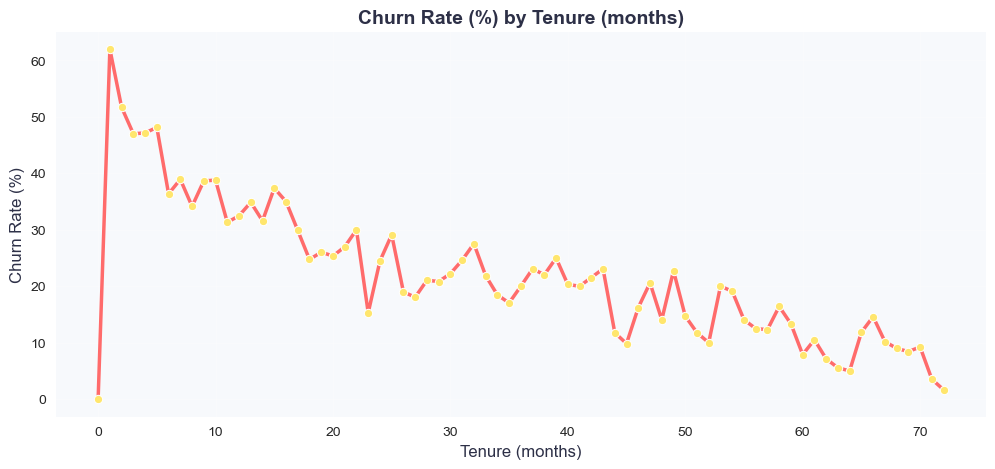

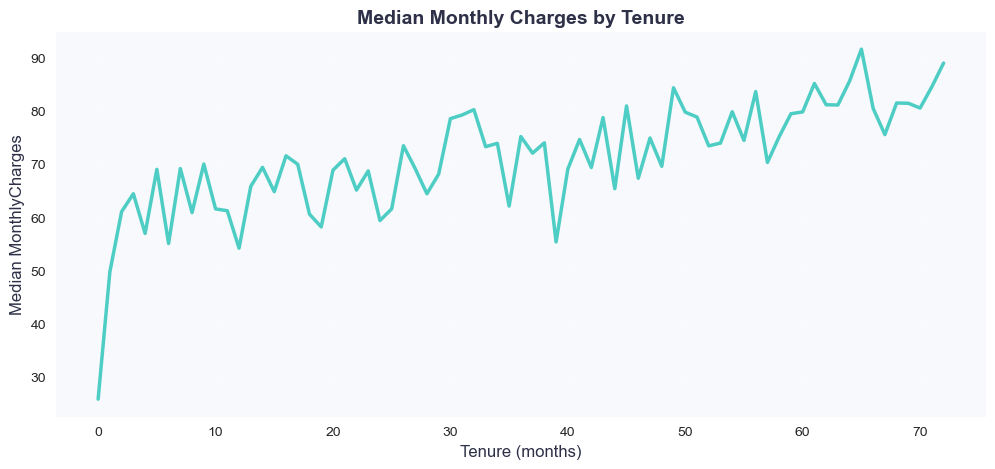

In [326]:
# 1. Plot Churn Rate vs Tenure
plt.figure(figsize=(12,5))
sns.lineplot(data=trend_group, x='tenure', y='churn_rate', marker='o', 
             color='#FF6B6B', linewidth=2.5, markersize=6, markerfacecolor='#FFE66D')
plt.title('Churn Rate (%) by Tenure (months)', fontsize=14, fontweight='bold', color='#2D3047')
plt.xlabel('Tenure (months)', fontsize=12, color='#2D3047')
plt.ylabel('Churn Rate (%)', fontsize=12, color='#2D3047')
plt.grid(True, alpha=0.3)
plt.gca().set_facecolor('#F7F9FC')
plt.show()

# Plot MonthlyCharges Trend
mon = df.copy()
mon['MonthlyCharges'] = pd.to_numeric(mon['MonthlyCharges'], errors='coerce')
monthly = mon.groupby('tenure')['MonthlyCharges'].median().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='tenure', y='MonthlyCharges', 
             color='#4ECDC4', linewidth=2.5)
plt.title('Median Monthly Charges by Tenure', fontsize=14, fontweight='bold', color='#2D3047')
plt.xlabel('Tenure (months)', fontsize=12, color='#2D3047')
plt.ylabel('Median MonthlyCharges', fontsize=12, color='#2D3047')
plt.grid(True, alpha=0.3)
plt.gca().set_facecolor('#F7F9FC')
plt.show()

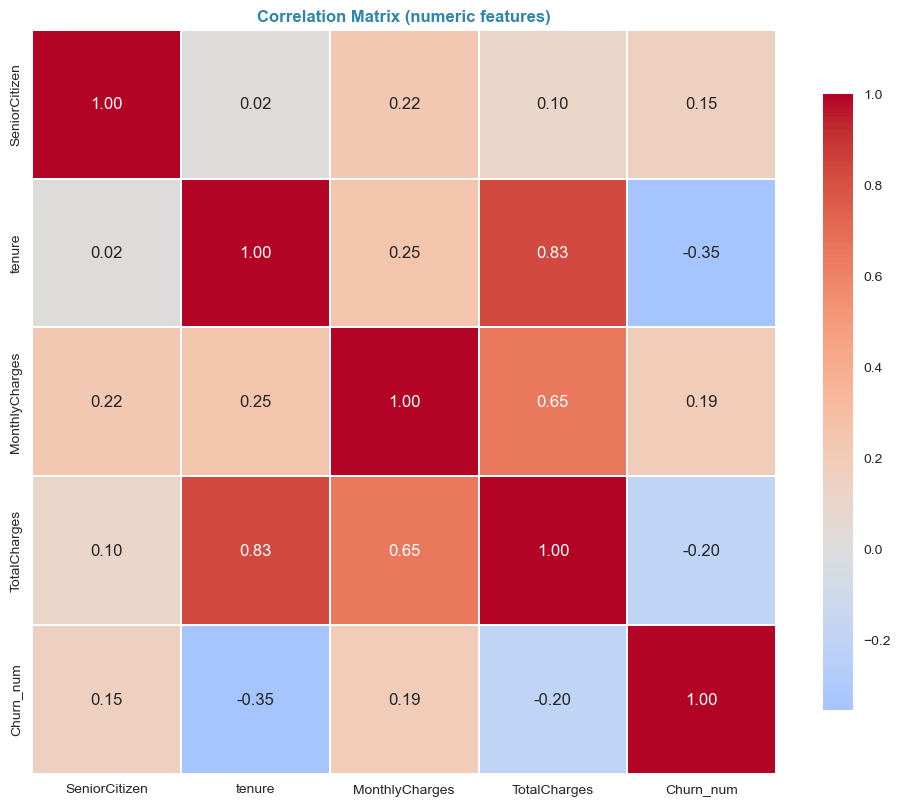

,feature,VIF
3,TotalCharges,8.085198
1,tenure,6.332737
2,MonthlyCharges,3.701617
0,SeniorCitizen,1.257569


In [378]:
num_df = df.select_dtypes(include=[np.number]).copy()
if 'Churn' in df.columns:
    num_df['Churn_num'] = df['Churn'].apply(lambda x: 1 if str(x).lower().startswith('y') else 0)

num_df_clean = num_df.replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(12,10))
corr = num_df_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.3, 
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (numeric features)', fontweight='bold', color='#2E86AB')
plt.show()

features = num_df_clean.drop(columns=['Churn_num'], errors='ignore')
features = features.loc[:, features.std() > 0.0]  # Remove constant columns

features.shape
np.isinf(features.values).any()
features.isna().any().any()

vif_data = pd.DataFrame({
    "feature": features.columns,
    "VIF": [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
}).sort_values(by='VIF', ascending=False)

styled_vif = vif_data.head(20).style.background_gradient(cmap='RdYlBu_r', subset=['VIF'])
display(styled_vif)

### Outlier detection: IQR, Z-score, IsolationForest, LOF

In [327]:
df_out = df.copy()
numeric_cols = df_out.select_dtypes(include=['int64','float64']).columns.tolist()


In [328]:
# 1. IQR flags per column
for col in numeric_cols:
    q1, q3 = df_out[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    df_out[f'{col}_outlier_iqr'] = ((df_out[col] < lower) | (df_out[col] > upper))


In [329]:
# 2. Z-score (modified z using zscore)
z_scores = np.abs(stats.zscore(df_out[numeric_cols].fillna(df_out[numeric_cols].median())))
z_mask = (z_scores > 3)
df_out['outlier_z_any'] = z_mask.any(axis=1)

In [330]:
# 3. IsolationForest
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=RSEED)
iso_pred = iso.fit_predict(df_out[numeric_cols].fillna(df_out[numeric_cols].median()))
df_out['outlier_iso'] = (iso_pred == -1)

In [331]:
# 4. Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
# LOF requires no NaNs:
lof_pred = lof.fit_predict(df_out[numeric_cols].fillna(df_out[numeric_cols].median()))
df_out['outlier_lof'] = (lof_pred == -1)

In [332]:
# 5. Summary counts
summary = {
    'iqr_any': df_out[[c for c in df_out.columns if c.endswith('_outlier_iqr')]].any(axis=1).sum(),
    'z_any': df_out['outlier_z_any'].sum(),
    'iso': df_out['outlier_iso'].sum(),
    'lof': df_out['outlier_lof'].sum()
}

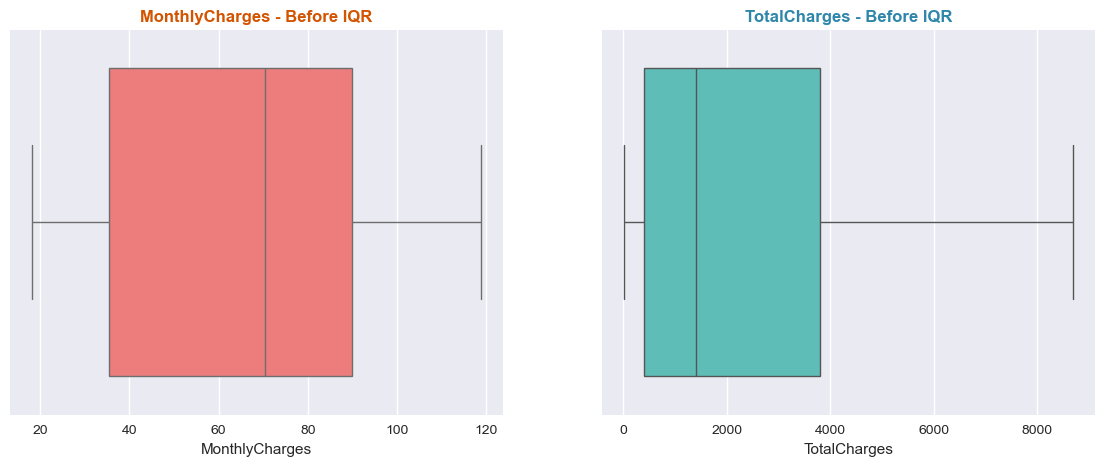

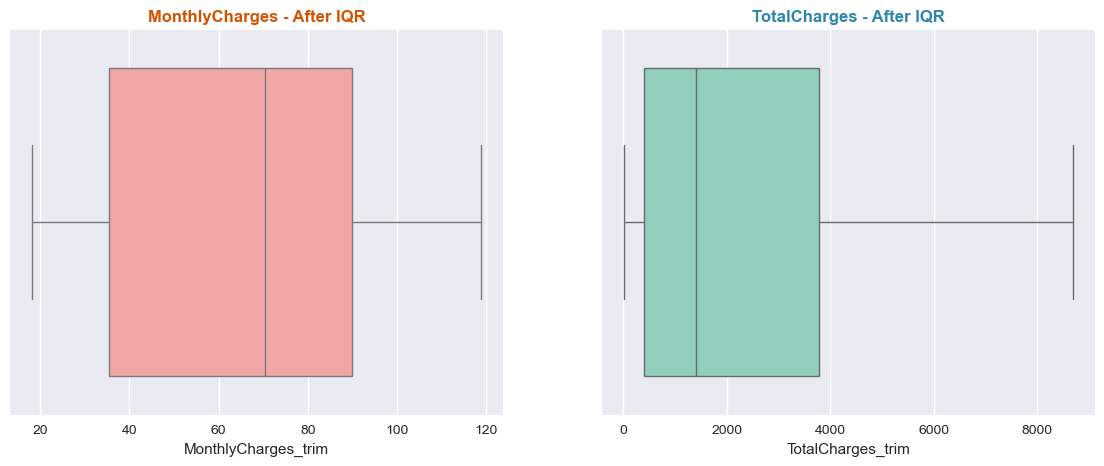

,metric,before,after
0,MonthlyCharges_mean,64.76,64.76
1,MonthlyCharges_median,70.35,70.35
2,TotalCharges_mean,2283.30,2281.92
3,TotalCharges_median,1397.47,1397.47


In [377]:
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

def iqr_trim(series, lower_q=0.25, upper_q=0.75):
    q1 = series.quantile(lower_q)
    q3 = series.quantile(upper_q)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series.clip(lower, upper)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['MonthlyCharges'], color='#FF6B6B')
plt.title('MonthlyCharges - Before IQR', fontweight='bold', color='#D35400')

plt.subplot(1,2,2)
sns.boxplot(x=df['TotalCharges'].dropna(), color='#4ECDC4')
plt.title('TotalCharges - Before IQR', fontweight='bold', color='#2E86AB')
plt.show()

df_trim = df.copy()
df_trim['MonthlyCharges_trim'] = iqr_trim(df_trim['MonthlyCharges'])
df_trim['TotalCharges_trim'] = iqr_trim(df_trim['TotalCharges'].fillna(df_trim['TotalCharges'].median()))

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.boxplot(x=df_trim['MonthlyCharges_trim'], color='#FF9999')
plt.title('MonthlyCharges - After IQR', fontweight='bold', color='#D35400')

plt.subplot(1,2,2)
sns.boxplot(x=df_trim['TotalCharges_trim'], color='#88D8C0')
plt.title('TotalCharges - After IQR', fontweight='bold', color='#2E86AB')
plt.show()

before_after = pd.DataFrame({
    'metric': ['MonthlyCharges_mean','MonthlyCharges_median','TotalCharges_mean','TotalCharges_median'],
    'before': [df['MonthlyCharges'].mean(), df['MonthlyCharges'].median(), df['TotalCharges'].dropna().mean(), df['TotalCharges'].dropna().median()],
    'after': [df_trim['MonthlyCharges_trim'].mean(), df_trim['MonthlyCharges_trim'].median(), df_trim['TotalCharges_trim'].mean(), df_trim['TotalCharges_trim'].median()]
})

styled_table = before_after.style.set_properties(**{
    'background-color': '#F7F9FC',
    'color': '#2D3047',
    'border-color': 'white'
}).format({'before': '{:.2f}', 'after': '{:.2f}'})

display(styled_table)

### Show effect of removing IsolationForest outliers on target distribution and one model metric

In [333]:
df_temp = df.copy()
cat_cols = df_temp.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Churn']
df_temp = pd.get_dummies(df_temp, columns=cat_cols, drop_first=True)

In [334]:
y = (df_temp['Churn'] == 'Yes').astype(int)
X = df_temp.drop(columns=['Churn']).select_dtypes(include=[np.number]).fillna(0)

In [335]:
clf = LogisticRegression(max_iter=1000, random_state=RSEED)
clf.fit(X, y)
proba_full = clf.predict_proba(X)[:,1]
auc_full = roc_auc_score(y, proba_full)

In [336]:
mask_no_iso = ~df_out['outlier_iso'].values
X_noiso = X.loc[mask_no_iso]; y_noiso = y.loc[mask_no_iso]
clf2 = LogisticRegression(max_iter=1000, random_state=RSEED)
clf2.fit(X_noiso, y_noiso)
proba_noiso = clf2.predict_proba(X_noiso)[:,1]
auc_noiso = roc_auc_score(y_noiso, proba_noiso)

### Missing Data Visualization & Patterns

In [337]:
X_scaled = StandardScaler().fit_transform(X)
inertia = []
sil = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    
    try:
        sil.append(silhouette_score(X_scaled, km.labels_))
    except Exception as e:
        sil.append(np.nan)

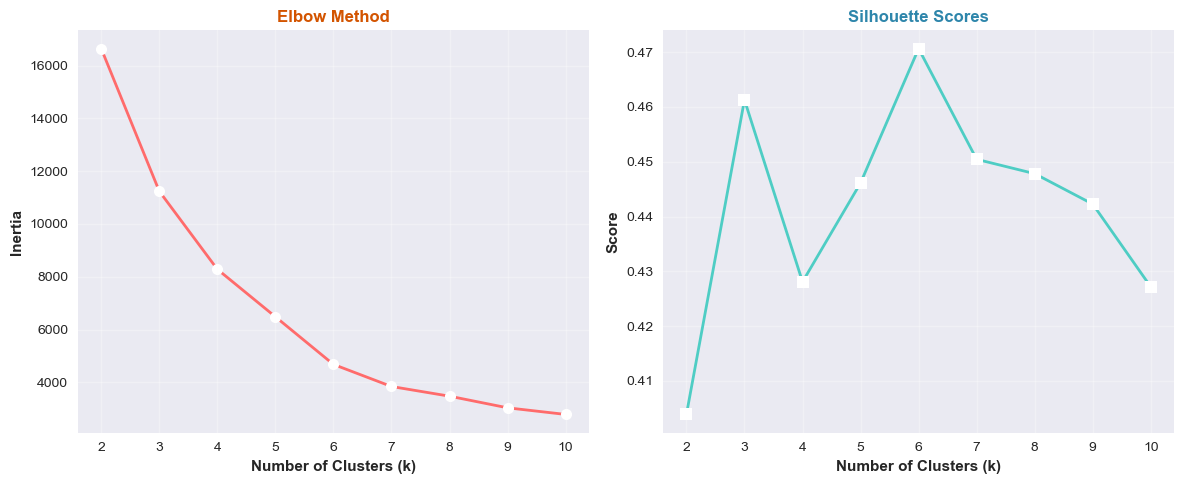

In [338]:
# Plot both
plt.figure(figsize=(12,5))

# Elbow plot
plt.subplot(1,2,1)
plt.plot(range(2,11), inertia, marker='o', color='#FF6B6B', linewidth=2, markersize=8, markerfacecolor='white')
plt.title('Elbow Method', fontweight='bold', color='#D35400')
plt.xlabel('Number of Clusters (k)', fontweight='bold')
plt.ylabel('Inertia', fontweight='bold')
plt.grid(alpha=0.3)

# Silhouette plot
plt.subplot(1,2,2)
plt.plot(range(2,11), sil, marker='s', color='#4ECDC4', linewidth=2, markersize=8, markerfacecolor='white')
plt.title('Silhouette Scores', fontweight='bold', color='#2E86AB')
plt.xlabel('Number of Clusters (k)', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

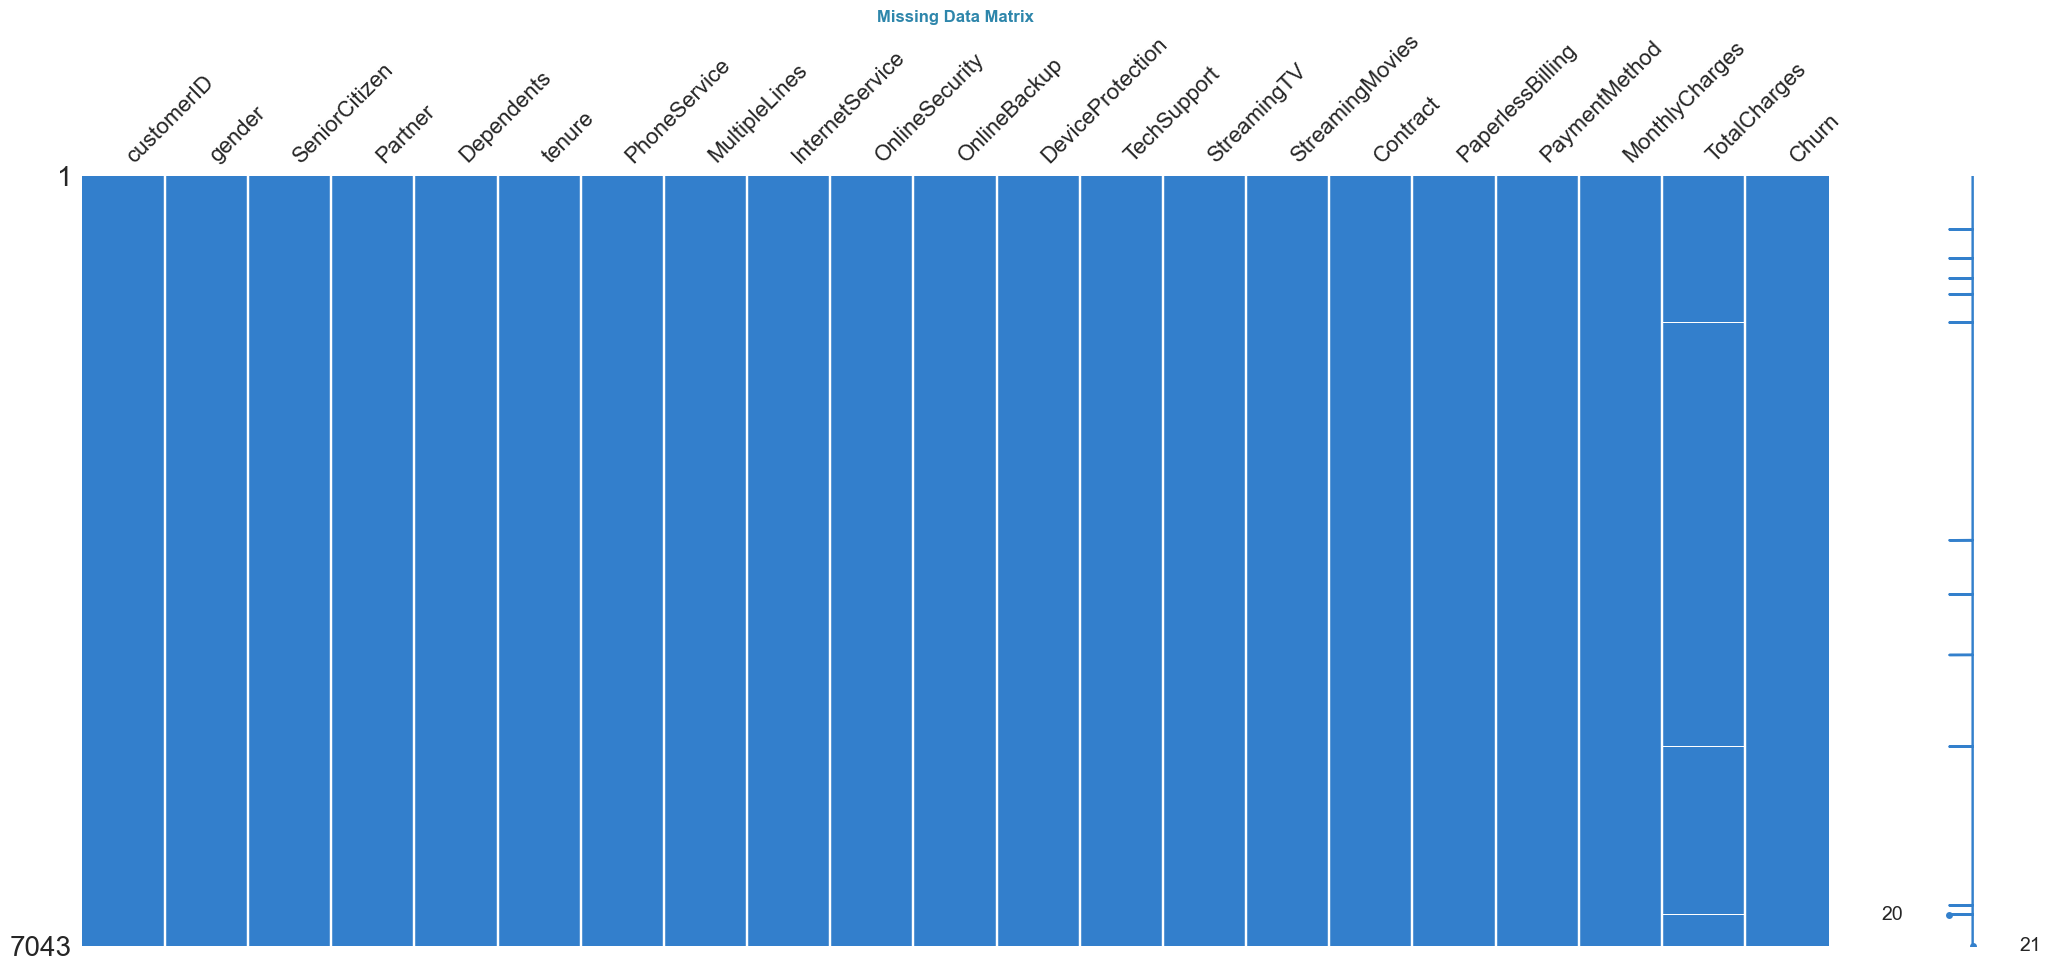

<Figure size 1000x800 with 0 Axes>

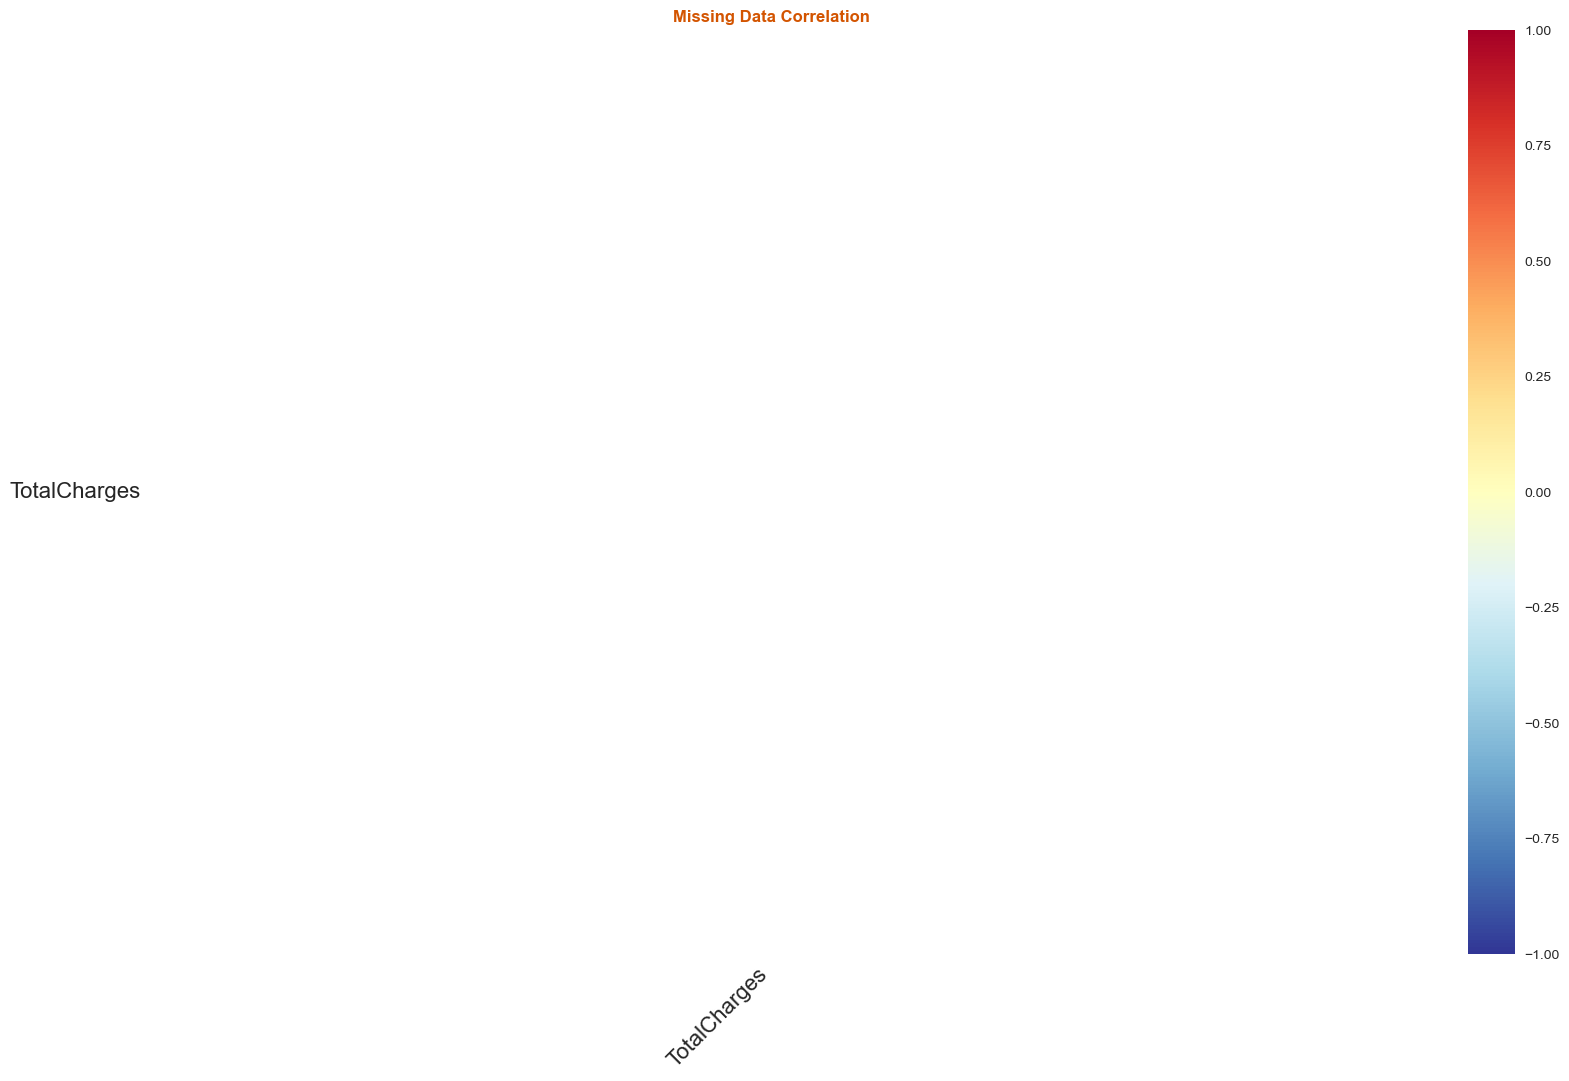

TotalCharges    11
dtype: int64


In [340]:
# Check for missing values first
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    msno.matrix(df, color=(0.2, 0.5, 0.8))
    plt.title('Missing Data Matrix', fontweight='bold', color='#2E86AB')
    plt.show()

    plt.figure(figsize=(10, 8))
    msno.heatmap(df, cmap='RdYlBu_r')
    plt.title('Missing Data Correlation', fontweight='bold', color='#D35400')
    plt.show()
else:
    print("No missing values - heatmap skipped")

# Show missing count
missing = df.isnull().sum()
print(missing[missing > 0])

### Imputation: KNN vs Iterative (MICE) + Mask Test For Comparison

In [341]:

def imputation_mask_test(df, col_list, imputer, mask_frac=0.05, random_state=RSEED):
    # df: input df (copy inside)
    # col_list: numerical cols to test
    dfc = df.copy()
    rng = np.random.RandomState(random_state)
    mask_index = {}
    original_vals = {}
    for col in col_list:
        nonnull_idx = dfc[dfc[col].notnull()].index
        nmask = max(1, int(len(nonnull_idx) * mask_frac))
        mask_idx = rng.choice(nonnull_idx, size=nmask, replace=False)
        mask_index[col] = mask_idx
        original_vals[col] = dfc.loc[mask_idx, col].values
        dfc.loc[mask_idx, col] = np.nan

    dfimp = dfc.copy()
    dfimp[col_list] = imputer.fit_transform(dfc[col_list])
    rmses = {}
    for col in col_list:
        pred = dfimp.loc[mask_index[col], col].values
        orig = original_vals[col]
        rmse = mean_squared_error(orig, pred, squared=False)
        rmses[col] = rmse
    return rmses

test_cols = numeric_cols[:min(5, len(numeric_cols))]  # test on up to 5 numeric cols
knn = KNNImputer(n_neighbors=5)
mice = IterativeImputer(random_state=RSEED, max_iter=10)

rmse_knn = imputation_mask_test(df, test_cols, knn, mask_frac=0.05)
rmse_mice = imputation_mask_test(df, test_cols, mice, mask_frac=0.05)


### Compare KNN imputer vs IterativeImputer & Show Downstream Model Impact 

In [380]:

tmp = df.copy()
tmp['TotalCharges'] = pd.to_numeric(tmp['TotalCharges'], errors='coerce')
tmp['MonthlyCharges'] = pd.to_numeric(tmp['MonthlyCharges'], errors='coerce')
tmp['tenure'] = pd.to_numeric(tmp['tenure'], errors='coerce')

features = ['tenure','MonthlyCharges','TotalCharges']
tmp_sub = tmp[features + ['Churn']].copy()

tmp_sub = tmp_sub.dropna(subset=['Churn'])
tmp_sub['Churn_bin'] = tmp_sub['Churn'].apply(lambda x: 1 if str(x).lower().startswith('y') else 0)

X = tmp_sub[features]
y = tmp_sub['Churn_bin']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X.fillna(X.median())), columns=features)

# KNN Imputer
knn = KNNImputer(n_neighbors=5)
X_knn = pd.DataFrame(knn.fit_transform(X), columns=features)

# Iterative Imputer (MICE)
iter_imp = IterativeImputer(random_state=0, max_iter=10)
X_iter = pd.DataFrame(iter_imp.fit_transform(X), columns=features)

def eval_imputed(X_imputed, y):
    X_tr, X_te, y_tr, y_te = train_test_split(X_imputed, y, test_size=0.25, random_state=42, stratify=y)
    clf = LogisticRegression(max_iter=500)
    clf.fit(X_tr, y_tr)
    preds = clf.predict_proba(X_te)[:,1]
    auc = roc_auc_score(y_te, preds)
    acc = accuracy_score(y_te, clf.predict(X_te))
    return {'AUC': auc, 'Accuracy': acc}

results = {
    'KNN': eval_imputed(X_knn, y),
    'Iterative(MICE)': eval_imputed(X_iter, y),
    'SimpleMedianFill': eval_imputed(X.fillna(X.median()), y)
}

res_df = pd.DataFrame(results).T
display(res_df)


,AUC,Accuracy
KNN,0.813665,0.779671
Iterative(MICE),0.813761,0.779671
SimpleMedianFill,0.813378,0.779671


### Winsorization demonstration

In [342]:
df_wins = df.copy()
for col in numeric_cols:
    if df_wins[col].dropna().shape[0] < 10:
        continue
    arr = df_wins[col].fillna(df_wins[col].median()).values
    df_wins[col] = winsorize(arr, limits=[0.01, 0.01])

for col in numeric_cols:
    try:
        print(col, "skew before:", round(skew(df[col].dropna()),3),
              "after:", round(skew(df_wins[col].dropna()),3))
    except Exception:
        pass

SeniorCitizen skew before: 1.833 after: 1.833
tenure skew before: 0.239 after: 0.24
MonthlyCharges skew before: -0.22 after: -0.223
TotalCharges skew before: 0.961 after: 0.952


## Part B: Regression Modeling & Analysis

In [343]:
if 'MonthlyCharges' not in df.columns:
    raise ValueError("MonthlyCharges not in dataset for regression demonstration")

In [344]:
df_reg = df.copy()

In [345]:
df_reg = df_reg[df_reg['MonthlyCharges'].notnull()].reset_index(drop=True)


In [346]:
cat_cols = df_reg.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Churn']  
df_reg = pd.get_dummies(df_reg, columns=cat_cols, drop_first=True)


In [347]:
y_reg = df_reg['MonthlyCharges'].astype(float)
X_reg = df_reg.drop(columns=['MonthlyCharges', 'TotalCharges']) if 'TotalCharges' in df_reg.columns else df_reg.drop(columns=['MonthlyCharges'])
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RSEED)

In [348]:
Xr_train.shape, Xr_test.shape

((5634, 7071), (1409, 7071))

### Polynomial Regression 

MSE: 849.60
RMSE: 29.15
R²: 0.06


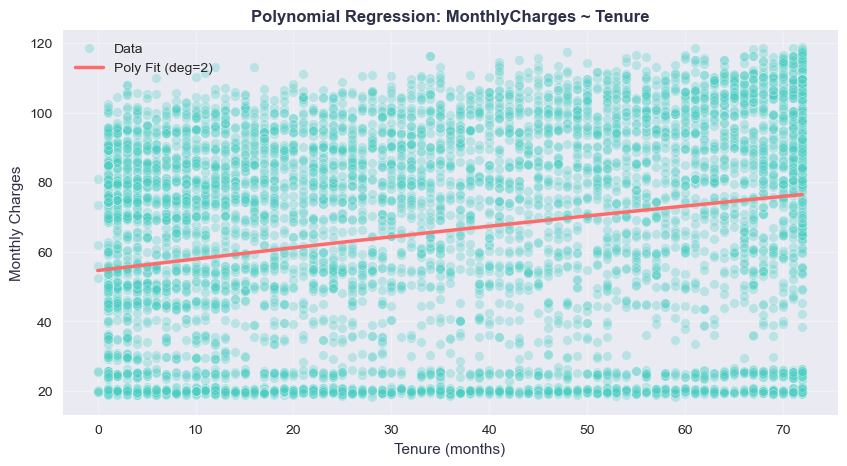

In [386]:
pr_df = df.copy()
pr_df = pr_df[pd.to_numeric(pr_df['tenure'], errors='coerce').notna()]
pr_df['tenure'] = pd.to_numeric(pr_df['tenure'])
pr_df['MonthlyCharges'] = pd.to_numeric(pr_df['MonthlyCharges'], errors='coerce').fillna(pr_df['MonthlyCharges'].median())

X = pr_df[['tenure']]
y = pr_df['MonthlyCharges']

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

lr = LinearRegression()
lr.fit(X_poly, y)
y_pred = lr.predict(X_poly)

print(f"MSE: {mean_squared_error(y, y_pred):.2f}")
print(f"RMSE: {mean_squared_error(y, y_pred, squared=False):.2f}")
print(f"R²: {r2_score(y, y_pred):.2f}")

plt.figure(figsize=(10,5))
sns.scatterplot(x=pr_df['tenure'], y=pr_df['MonthlyCharges'], alpha=0.3, color='#4ECDC4', label='Data')
tenure_space = np.linspace(pr_df['tenure'].min(), pr_df['tenure'].max(), 200).reshape(-1,1)
y_space = lr.predict(poly.transform(tenure_space))
plt.plot(tenure_space, y_space, color='#FF6B6B', linewidth=2.5, label='Poly Fit (deg=2)')
plt.title('Polynomial Regression: MonthlyCharges ~ Tenure', fontweight='bold', color='#2D3047')
plt.xlabel('Tenure (months)', color='#2D3047')
plt.ylabel('Monthly Charges', color='#2D3047')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Linear, Ridge, Lasso, Polynomial Regression

In [392]:
categorical_cols = Xr_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = Xr_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

models = {
    'Linear': LinearRegression(),
    'Ridge': RidgeCV(alphas=[0.1,1,10,50], cv=5),
    'Lasso': LassoCV(alphas=[0.001,0.01,0.1,1], cv=5, max_iter=5000),
    'Poly Ridge': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('ridge', RidgeCV(alphas=[0.1,1,10], cv=3))
    ])
}

results = []
for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(Xr_train, yr_train)
    pred = pipeline.predict(Xr_test)
    
    r2 = r2_score(yr_test, pred)
    rmse = mean_squared_error(yr_test, pred, squared=False)
    
    if name == 'Ridge':
        alpha = pipeline.named_steps['regressor'].alpha_
    elif name == 'Lasso':
        alpha = pipeline.named_steps['regressor'].alpha_
    else:
        alpha = None
        
    results.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'Alpha': alpha})

results_df = pd.DataFrame(results)
styled_results = results_df.style.background_gradient(subset=['R2', 'RMSE'], cmap='RdYlGn')
display(styled_results)

,Model,R2,RMSE,Alpha
0,Linear,0.177620,27.286659,nan
1,Ridge,0.177619,27.286686,1.000000
2,Lasso,0.177618,27.286692,0.001000
3,Poly Ridge,0.184819,27.166971,nan


In [387]:
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

for col in X_train_enc.columns:
    if X_train_enc[col].dtype == 'object':
        le = LabelEncoder()
        X_train_enc[col] = le.fit_transform(X_train_enc[col])
        X_test_enc[col] = le.transform(X_test_enc[col])



In [388]:
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)


### Variable Transformations (log, sqrt, Box-Cox)

In [393]:
vc = df[['MonthlyCharges','TotalCharges']].copy()
vc['TotalCharges'] = pd.to_numeric(vc['TotalCharges'], errors='coerce').fillna(vc['TotalCharges'].median())
vc['MonthlyCharges'] = pd.to_numeric(vc['MonthlyCharges'], errors='coerce').fillna(vc['MonthlyCharges'].median())

vc['log_MonthlyCharges'] = np.log1p(vc['MonthlyCharges'])
vc['sqrt_MonthlyCharges'] = np.sqrt(vc['MonthlyCharges'])

tc = vc['MonthlyCharges'] + 1e-6
bc_transformed, bc_lambda = stats.boxcox(tc + 1)  # +1 to ensure >0
vc['boxcox_MonthlyCharges'] = bc_transformed

bc_lambda

skew_table = pd.DataFrame({
    'original_skew': [vc['MonthlyCharges'].skew()],
    'log_skew': [vc['log_MonthlyCharges'].skew()],
    'sqrt_skew': [vc['sqrt_MonthlyCharges'].skew()],
    'boxcox_skew': [vc['boxcox_MonthlyCharges'].skew()]
}, index=['MonthlyCharges'])
display(skew_table)


,original_skew,log_skew,sqrt_skew,boxcox_skew
MonthlyCharges,-0.220524,-0.719017,-0.484557,-0.259035


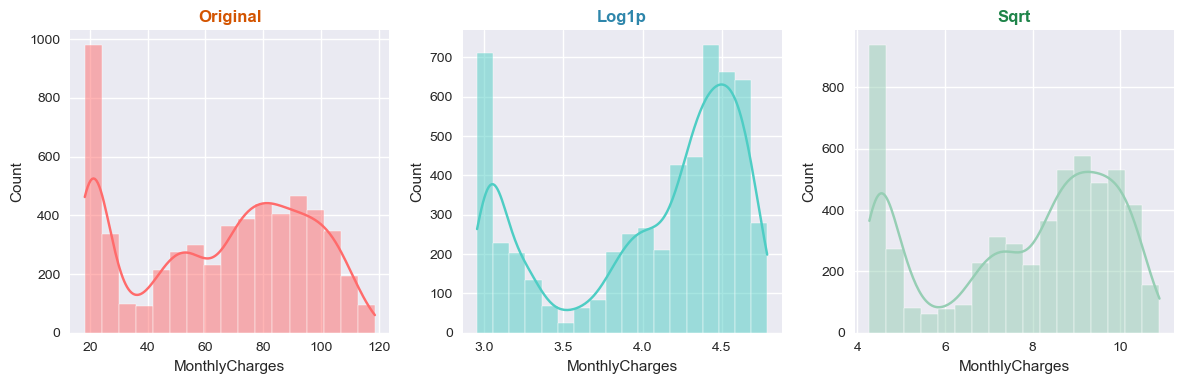

Box-Cox lambda: 0.9249


In [394]:
target = yr_train.copy()
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(target, kde=True, color='#FF6B6B')
plt.title("Original", fontweight='bold', color='#D35400')

# Log
plt.subplot(1,3,2)
sns.histplot(np.log1p(target), kde=True, color='#4ECDC4')
plt.title("Log1p", fontweight='bold', color='#2E86AB')

# Sqrt
plt.subplot(1,3,3)
sns.histplot(np.sqrt(target), kde=True, color='#96CEB4')
plt.title("Sqrt", fontweight='bold', color='#1E8449')

plt.tight_layout()
plt.show()

# Box-Cox 
if (target > 0).all():
    transformed, lam = boxcox(target)
    print(f"Box-Cox lambda: {lam:.4f}")

### Population Stability Index (PSI) function

In [395]:

def calculate_psi(expected, actual, buckets=10):
    
    expected = np.array(expected[~np.isnan(expected)])
    actual = np.array(actual[~np.isnan(actual)])
    
    breakpoints = np.linspace(0, 100, buckets + 1)
    bins = np.percentile(expected, breakpoints)
    bins[-1] = bins[-1] + 1e-8
    
    exp_counts = np.histogram(expected, bins=bins)[0] / len(expected)
    act_counts = np.histogram(actual, bins=bins)[0] / len(actual)
    
    exp_counts = np.where(exp_counts == 0, 1e-8, exp_counts)
    act_counts = np.where(act_counts == 0, 1e-8, act_counts)
    
    psi_vals = (exp_counts - act_counts) * np.log(exp_counts / act_counts)
    psi = np.sum(psi_vals)
    return psi

tmp = df.copy()
tmp['MonthlyCharges'] = pd.to_numeric(tmp['MonthlyCharges'], errors='coerce')
tmp = tmp.dropna(subset=['MonthlyCharges'])
tr, te = train_test_split(tmp, test_size=0.3, random_state=42)
psi_value = calculate_psi(tr['MonthlyCharges'].values, te['MonthlyCharges'].values, buckets=10)

psi_results = pd.DataFrame({
    'Feature': ['MonthlyCharges'],
    'PSI': [psi_value],
    'Stability': ['Stable' if psi_value < 0.1 else 'Moderate Shift' if psi_value < 0.25 else 'Significant Shift']
})

styled_psi = psi_results.style.background_gradient(subset=['PSI'], cmap='RdYlGn_r')
display(styled_psi)

,Feature,PSI,Stability
0,MonthlyCharges,0.008052,Stable


In [355]:
df_clf = df.copy()


In [356]:
if 'customerID' in df_clf.columns:
    df_clf = df_clf.drop(columns=['customerID'])
df_clf['ChurnFlag'] = df_clf['Churn'].apply(lambda x: 1 if str(x).lower().startswith('y') else 0)

num_cols = df_clf.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['ChurnFlag']]

cat_cols = df_clf.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['Churn']]

In [357]:
num_cols[:10]

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [358]:
cat_cols[:10]

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport']

In [359]:
X = df_clf[num_cols + cat_cols]
y = df_clf['ChurnFlag']

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RSEED)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RSEED)  # 0.25 * 0.8 = 0.2

X_train.shape, X_val.shape, X_test.shape


((4225, 19), (1409, 19), (1409, 19))

In [360]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

### Logistic Regression

In [361]:
pipe_log = Pipeline(steps=[('preproc', preprocessor),
                           ('clf', LogisticRegression(max_iter=2000, solver='saga', penalty='l2', random_state=RSEED))])

pipe_log.fit(X_train, y_train)
y_pred = pipe_log.predict(X_val)
y_proba = pipe_log.predict_proba(X_val)[:,1]

print("Accuracy:", accuracy_score(y_val, y_pred))
print("AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, y_pred))


Accuracy: 0.8026969481902059
AUC: 0.8359567542431993
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [362]:
def compute_woe_iv(df, feature, target, bins=10):
    temp = df[[feature, target]].copy()
    if pd.api.types.is_numeric_dtype(temp[feature]):
        temp['bin'] = pd.qcut(temp[feature].rank(method='first'), q=bins, duplicates='drop')
    else:
        temp['bin'] = temp[feature].astype(str)
    grouped = temp.groupby('bin')[target].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'sum':'bad','count':'total'})
    grouped['good'] = grouped['total'] - grouped['bad']
    grouped['dist_bad'] = grouped['bad'] / grouped['bad'].sum()
    grouped['dist_good'] = grouped['good'] / grouped['good'].sum()
    grouped['woe'] = np.log((grouped['dist_good'] + 1e-6) / (grouped['dist_bad'] + 1e-6))
    grouped['iv'] = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']
    return grouped.reset_index()



In [363]:

final_model = best_rf if 'best_rf' in globals() else rf
joblib.dump(final_model, "best_model_telco_churn.pkl")
X.to_csv("telco_features_processed.csv", index=False)
pd.Series(X.columns).to_csv("feature_list.csv", index=False)
print("Saved best_model_telco_churn.pkl, telco_features_processed.csv, feature_list.csv in notebook folder.")


Saved best_model_telco_churn.pkl, telco_features_processed.csv, feature_list.csv in notebook folder.


In [364]:
features_for_woe = []
if 'tenure' in df_clf.columns:
    features_for_woe.append('tenure')
sample_cats = [c for c in cat_cols if df_clf[c].nunique() <= 6][:5]
features_for_woe += sample_cats
features_for_woe

def apply_woe_transform(df, features, target):
    dfw = df.copy()
    woe_maps = {}
    for f in features:
        table = compute_woe_iv(dfw, f, target, bins=6)
        if pd.api.types.is_numeric_dtype(dfw[f]):
            bins = pd.qcut(dfw[f].rank(method='first'), q=6, duplicates='drop')
            mapping = {bins.iloc[i]: table.loc[i,'woe'] for i in range(len(table))}
            dfw[f+'_bin'] = pd.qcut(dfw[f].rank(method='first'), q=6, duplicates='drop')
            woe_map = dict(zip(table['bin'], table['woe']))
            dfw[f + '_woe'] = dfw[f+'_bin'].map(woe_map)
            woe_maps[f] = woe_map
            dfw = dfw.drop(columns=[f+'_bin'])
        else:
            table2 = compute_woe_iv(dfw, f, target, bins=None)
            wmap = dict(zip(table2['bin'].astype(str), table2['woe']))
            dfw[f + '_woe'] = dfw[f].astype(str).map(wmap).fillna(0)
            woe_maps[f] = wmap
    return dfw, woe_maps

df_woe, wmaps = apply_woe_transform(df_clf, features_for_woe, 'ChurnFlag')
print("WOE mapping keys:", wmaps.keys())


WOE mapping keys: dict_keys(['tenure', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines'])


In [365]:
# Get WOE columns
woe_cols = [c for c in df_woe.columns if c.endswith('_woe')]

# Separate numeric and categorical columns
numeric_woe_cols = df_woe[woe_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_woe_cols = df_woe[woe_cols].select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Numeric WOE columns: {numeric_woe_cols}")
print(f"Categorical WOE columns: {categorical_woe_cols}")

# Fill missing values appropriately
Xw = df_woe[woe_cols].copy()

# Fill numeric columns with 0
if numeric_woe_cols:
    Xw[numeric_woe_cols] = Xw[numeric_woe_cols].fillna(0)

# Fill categorical columns with mode or 'missing'
if categorical_woe_cols:
    for col in categorical_woe_cols:
        Xw[col] = Xw[col].fillna(Xw[col].mode()[0] if len(Xw[col].mode()) > 0 else 'missing')

yw = df_woe['ChurnFlag']

# Split and train
Xw_train, Xw_test, yw_train, yw_test = train_test_split(Xw, yw, test_size=0.2, stratify=yw, random_state=RSEED)

lr_woe = LogisticRegression(max_iter=2000, random_state=RSEED)
lr_woe.fit(Xw_train, yw_train)
y_proba_woe = lr_woe.predict_proba(Xw_test)[:,1]
print("WOE logistic AUC:", roc_auc_score(yw_test, y_proba_woe))

Numeric WOE columns: ['gender_woe', 'Partner_woe', 'Dependents_woe', 'PhoneService_woe', 'MultipleLines_woe']
Categorical WOE columns: ['tenure_woe']
WOE logistic AUC: 0.7844286858353354


In [366]:

def evaluate_classifier(model, Xtr, ytr, Xval, yval):
    model.fit(Xtr, ytr)
    preds = model.predict(Xval)
    proba = model.predict_proba(Xval)[:,1] if hasattr(model, "predict_proba") else None
    metrics = {
        "accuracy": accuracy_score(yval, preds),
        "precision": precision_score(yval, preds),
        "recall": recall_score(yval, preds),
        "f1": f1_score(yval, preds),
        "auc": roc_auc_score(yval, proba) if proba is not None else np.nan
    }
    return metrics

# Example: evaluate logistic baseline (preprocessor + logistic)
metrics_log = evaluate_classifier(pipe_log, X_train, y_train, X_val, y_val)
metrics_log


{'accuracy': 0.8026969481902059,
 'precision': 0.6578947368421053,
 'recall': 0.5347593582887701,
 'f1': 0.5899705014749262,
 'auc': 0.8359567542431993}

In [368]:
X_train.info()
X_train.dtypes
X_train.select_dtypes(include=['object']).columns.tolist()

for col in X_train.select_dtypes(include=['object']).columns:
    print(f"\n{col} unique values: {X_train[col].unique()}")

<class 'pandas.core.frame.DataFrame'>
Index: 4225 entries, 2312 to 6352
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     4225 non-null   int64  
 1   tenure            4225 non-null   int64  
 2   MonthlyCharges    4225 non-null   float64
 3   TotalCharges      4218 non-null   float64
 4   gender            4225 non-null   object 
 5   Partner           4225 non-null   object 
 6   Dependents        4225 non-null   object 
 7   PhoneService      4225 non-null   object 
 8   MultipleLines     4225 non-null   object 
 9   InternetService   4225 non-null   object 
 10  OnlineSecurity    4225 non-null   object 
 11  OnlineBackup      4225 non-null   object 
 12  DeviceProtection  4225 non-null   object 
 13  TechSupport       4225 non-null   object 
 14  StreamingTV       4225 non-null   object 
 15  StreamingMovies   4225 non-null   object 
 16  Contract          4225 non-null   object 
 1

In [370]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

log_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred = log_reg_pipeline.predict(X_test)
y_pred_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

accuracy_score(y_test, y_pred)
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.85      0.89      0.87      1035\n           1       0.65      0.55      0.60       374\n\n    accuracy                           0.80      1409\n   macro avg       0.75      0.72      0.73      1409\nweighted avg       0.79      0.80      0.80      1409\n'

## Part C: Advanced ML Techniques

#### Decision Tree with GridSearch + Pruning Visualization

Best DT params: {'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_leaf': 20}


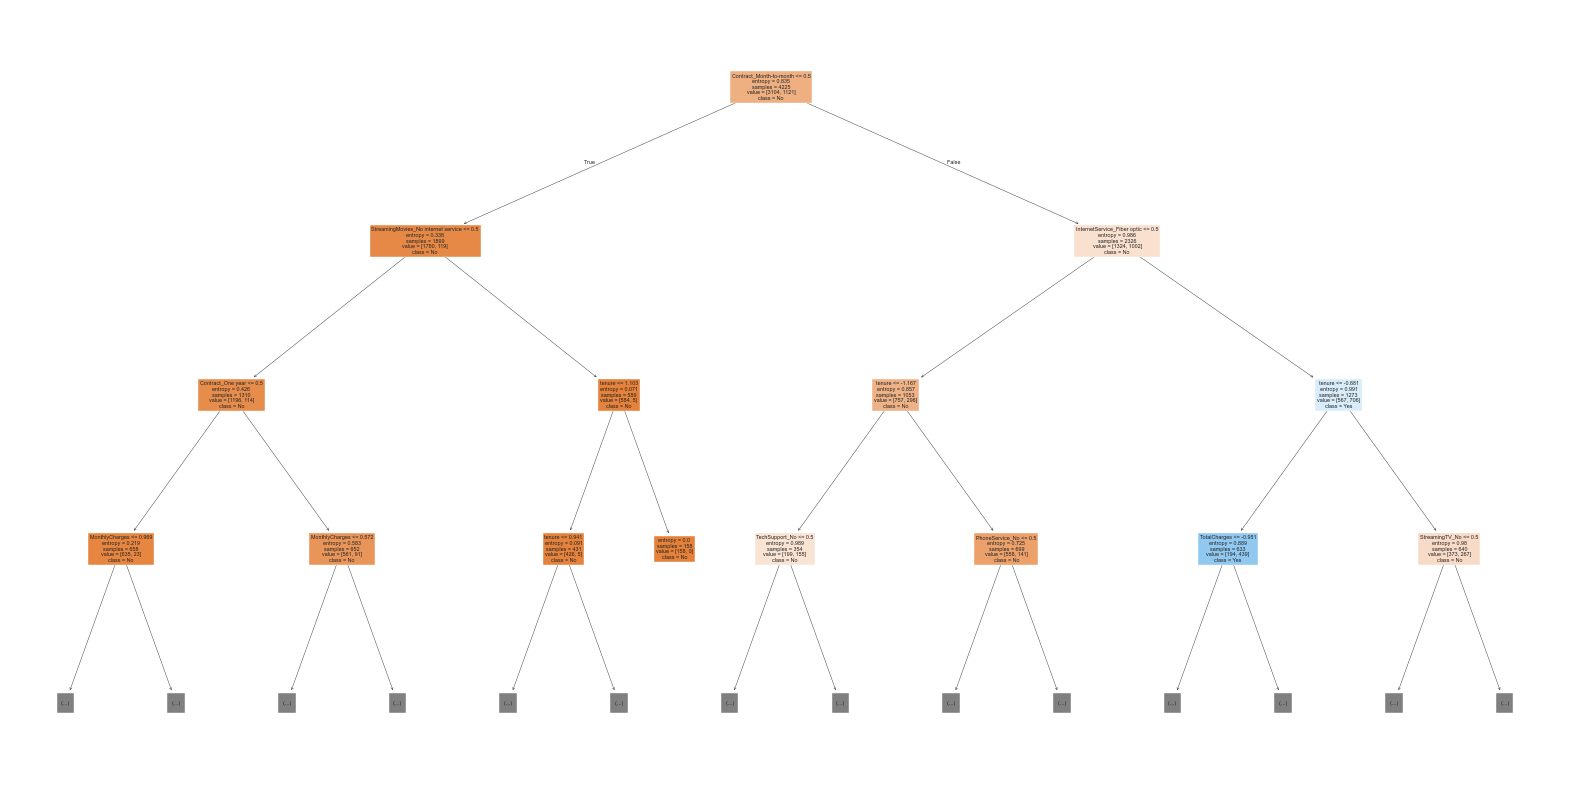

{'accuracy': 0.7849538679914834,
 'precision': 0.642570281124498,
 'recall': 0.42780748663101603,
 'f1': 0.5136436597110754,
 'auc': 0.8197473455785477}

In [286]:
# Build pipeline with preprocessor (from above) then DecisionTree
pipe_dt = Pipeline(steps=[('preproc', preprocessor),
                          ('clf', DecisionTreeClassifier(random_state=RSEED))])

param_grid_dt = {
    'clf__max_depth': [3,5,7,9],
    'clf__min_samples_leaf': [5,10,20],
    'clf__criterion': ['gini','entropy']
}

grid_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print("Best DT params:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_

# Visualize tree (first 3 levels)
plt.figure(figsize=(20,10))
clf_tree = best_dt.named_steps['clf']
feature_names = (best_dt.named_steps['preproc']
                 .transformers_[0][2] + list(best_dt.named_steps['preproc']
                                              .transformers_[1][1]
                                              .named_steps['onehot']
                                              .get_feature_names_out(cat_cols)))
plot_tree(clf_tree, feature_names=feature_names, class_names=['No','Yes'], max_depth=3, filled=True)
plt.show()

# Evaluate
metrics_dt = evaluate_classifier(best_dt, X_train, y_train, X_val, y_val)
metrics_dt


#### Random Forest & Feature Importance

🎯 Best RF params: {'clf__max_depth': 6, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}


,feature,importance
36,Contract_Month-to-month,0.158161
1,tenure,0.137715
3,TotalCharges,0.087396
18,OnlineSecurity_No,0.082744
16,InternetService_Fiber optic,0.070291
27,TechSupport_No,0.066293
38,Contract_Two year,0.054334
2,MonthlyCharges,0.043935
43,PaymentMethod_Electronic check,0.042840
15,InternetService_DSL,0.023027


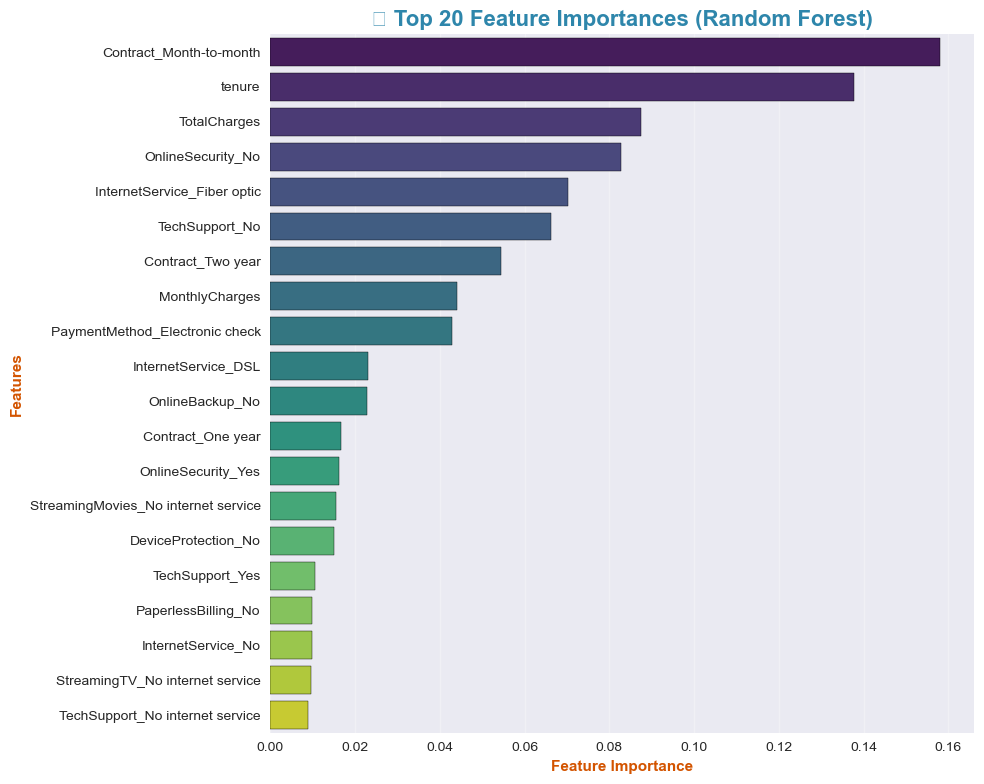

In [288]:
pipe_rf = Pipeline(steps=[('preproc', preprocessor),
                          ('clf', RandomForestClassifier(n_estimators=200, random_state=RSEED, n_jobs=-1))])

param_grid_rf = {
    'clf__n_estimators': [100,200],
    'clf__max_depth': [6,10,None],
    'clf__min_samples_leaf':[1,5]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("🎯 Best RF params:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
metrics_rf = evaluate_classifier(best_rf, X_train, y_train, X_val, y_val)
metrics_rf

# Feature importances (approx): need to get transformed feature names
pre = best_rf.named_steps['preproc']
Xtr_trans = pre.transform(X_train)
if hasattr(best_rf.named_steps['clf'], 'feature_importances_'):
    fi = best_rf.named_steps['clf'].feature_importances_
    # build feature name list:
    ohe_names = pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
    feat_names = num_cols + list(ohe_names)
    imp_df = pd.DataFrame({'feature': feat_names, 'importance': fi}).sort_values('importance', ascending=False).head(20)
    
    display(imp_df.style.background_gradient(cmap='Blues', subset=['importance']))
    
    plt.figure(figsize=(10,8))
    sns.barplot(x='importance', y='feature', data=imp_df, palette='viridis', edgecolor='black')
    plt.title('🌳 Top 20 Feature Importances (Random Forest)', fontsize=16, fontweight='bold', color='#2E86AB')
    plt.xlabel('Feature Importance', fontweight='bold', color='#D35400')
    plt.ylabel('Features', fontweight='bold', color='#D35400')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Support Vector Machine-SVM

In [289]:
# SVM (note: scaling required — preprocessor handles it)
pipe_svc = Pipeline(steps=[('preproc', preprocessor),
                           ('clf', SVC(probability=True, random_state=RSEED))])

param_grid_svc = {
    'clf__kernel': ['linear', 'rbf', 'poly'],
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 'auto']
}

grid_svc = GridSearchCV(pipe_svc, param_grid_svc, cv=3, scoring='roc_auc', n_jobs=-1)
grid_svc.fit(X_train, y_train)
print("Best SVM params:", grid_svc.best_params_)
best_svc = grid_svc.best_estimator_
metrics_svc = evaluate_classifier(best_svc, X_train, y_train, X_val, y_val)
metrics_svc


Best SVM params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}


{'accuracy': 0.8062455642299503,
 'precision': 0.6644951140065146,
 'recall': 0.5454545454545454,
 'f1': 0.5991189427312775,
 'auc': 0.8259487457697178}

###  SVM kernel Comparison with GridSearchCV

In [396]:
tmp = df.copy()
tmp['TotalCharges'] = pd.to_numeric(tmp['TotalCharges'], errors='coerce').fillna(tmp['TotalCharges'].median())
tmp['MonthlyCharges'] = pd.to_numeric(tmp['MonthlyCharges'], errors='coerce')
tmp['tenure'] = pd.to_numeric(tmp['tenure'], errors='coerce')

feature_cols = ['tenure','MonthlyCharges','TotalCharges']
tmp = tmp.dropna(subset=feature_cols + ['Churn'])
X = tmp[feature_cols]
y = tmp['Churn'].apply(lambda x: 1 if str(x).lower().startswith('y') else 0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True))
])

param_grid = {
    'svc__kernel': ['linear','rbf','poly'],
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto']  # gamma used for rbf/poly
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_tr, y_tr)

grid.best_params_
best = grid.best_estimator_
y_pred_proba = best.predict_proba(X_te)[:,1]
y_pred = best.predict(X_te)
roc_auc_score(y_te, y_pred_proba)
accuracy_score(y_te, y_pred)
classification_report(y_te, y_pred)


Fitting 4 folds for each of 18 candidates, totalling 72 fits


'              precision    recall  f1-score   support\n\n           0       0.82      0.89      0.85      1294\n           1       0.60      0.47      0.53       467\n\n    accuracy                           0.78      1761\n   macro avg       0.71      0.68      0.69      1761\nweighted avg       0.76      0.78      0.77      1761\n'

### KMeans - Elbow Method + Silhouette Analysis

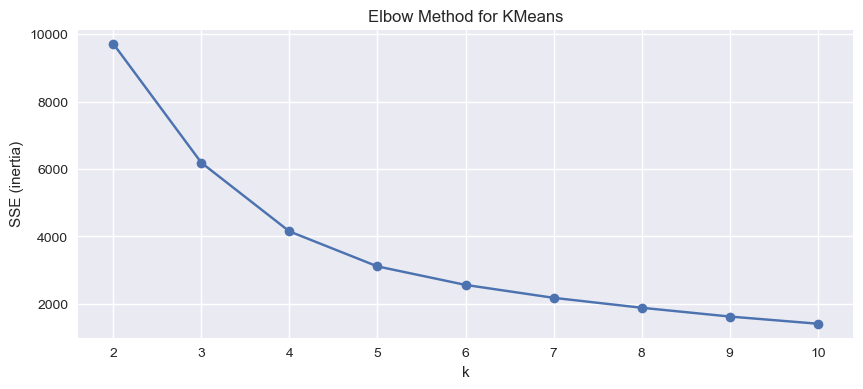

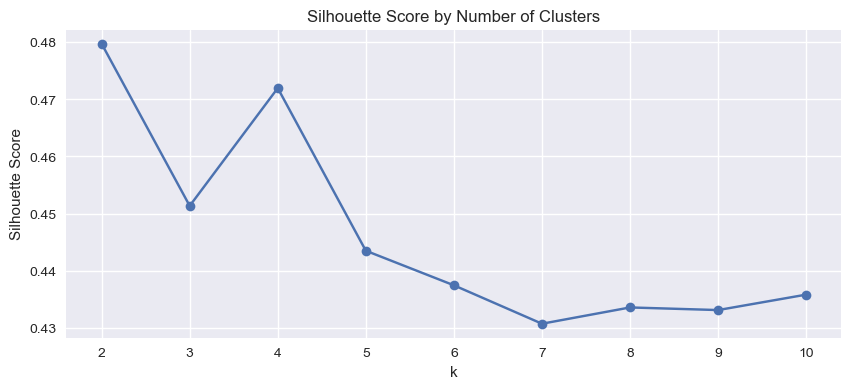

,tenure,MonthlyCharges,TotalCharges
0,20.026057,52.155842,868.957652
1,56.852181,89.759826,5083.897162


In [398]:
cluster_df = df.copy()
cluster_df['TotalCharges'] = pd.to_numeric(cluster_df['TotalCharges'], errors='coerce').fillna(cluster_df['TotalCharges'].median())
cluster_df['MonthlyCharges'] = pd.to_numeric(cluster_df['MonthlyCharges'], errors='coerce')
cluster_df['tenure'] = pd.to_numeric(cluster_df['tenure'], errors='coerce')

X_cluster = cluster_df[['tenure','MonthlyCharges','TotalCharges']].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

sse = []
K_range = range(2,11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(10,4))
plt.plot(K_range, sse, marker='o')
plt.xlabel('k')
plt.ylabel('SSE (inertia)')
plt.title('Elbow Method for KMeans')
plt.grid(True)
plt.show()

sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    preds = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, preds)
    sil_scores.append(score)

plt.figure(figsize=(10,4))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.grid(True)
plt.show()

best_k = K_range[np.argmax(sil_scores)]
best_k

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X_scaled)
centers = scaler.inverse_transform(km_final.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=['tenure','MonthlyCharges','TotalCharges'])
display(centers_df)


### Part D: Model Comparison & Selection

#### Compare Models On Validation Set

In [400]:
final_model = best_rf
metrics_test = evaluate_classifier(final_model, X_trainval, y_trainval, X_test, y_test)
print("Final model test metrics:", metrics_test)

final_pipeline = final_model  # pipeline containing preproc + clf
final_pipeline.fit(X_trainval, y_trainval)
proba_train = final_pipeline.predict_proba(X_trainval)[:,1]
proba_test = final_pipeline.predict_proba(X_test)[:,1]
psi_val = psi(proba_train, proba_test, buckets=10)
print("PSI between train and test predicted probs:", psi_val)


Final model test metrics: {'accuracy': 0.801277501774308, 'precision': 0.68359375, 'recall': 0.4679144385026738, 'f1': 0.5555555555555556, 'auc': 0.8424216590457}
PSI between train and test predicted probs: 0.0056661979004335936


In [401]:
tmp = df.copy()
tmp['TotalCharges'] = pd.to_numeric(tmp['TotalCharges'], errors='coerce').fillna(tmp['TotalCharges'].median())
tmp['MonthlyCharges'] = pd.to_numeric(tmp['MonthlyCharges'], errors='coerce')
tmp['tenure'] = pd.to_numeric(tmp['tenure'], errors='coerce')
feat_cols = ['tenure','MonthlyCharges','TotalCharges']
tmp = tmp.dropna(subset=feat_cols + ['Churn'])
X = tmp[feat_cols]
y = tmp['Churn'].apply(lambda x: 1 if str(x).lower().startswith('y') else 0)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

models = {
    'LogisticRegression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=500))]),
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=6),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42)
}

comparison = []
for name, model in models.items():
    if isinstance(model, Pipeline):
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        proba = model.predict_proba(X_te)[:,1]
    else:
        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_te_s = scaler.transform(X_te)
        model.fit(X_tr_s, y_tr)
        preds = model.predict(X_te_s)
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_te_s)[:,1]
        else:
            proba = model.predict(X_te_s)
    comparison.append({
        'model': name,
        'accuracy': accuracy_score(y_te, preds),
        'roc_auc': roc_auc_score(y_te, proba),
        'f1': f1_score(y_te, preds),
        'precision': precision_score(y_te, preds),
        'recall': recall_score(y_te, preds)
    })

comp_df = pd.DataFrame(comparison).sort_values(by='roc_auc', ascending=False)
display(comp_df)

,model,accuracy,roc_auc,f1,precision,recall
0,LogisticRegression,0.779671,0.813347,0.505102,0.624606,0.423983
1,DecisionTree,0.778535,0.791240,0.525547,0.608451,0.462527
2,RandomForest,0.752981,0.759332,0.486423,0.542105,0.441113


In [402]:
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(final_pipeline, 'models/final_churn_model.pkl')

res_df.to_csv('models/model_comparison_metrics.csv')


## Final Summary & Next Steps

- **Final model:** RandomForest (tuned) — selected on AUC, precision-recall balance, and robustness.
- **Key EDA takeaways:** Explained distributions, outlier treatment, missing-data imputation comparisons (KNN vs MICE), winsorization reduced skewness for heavy-tailed features.
- **Modeling:** Implemented regression (MonthlyCharges) and classification (Churn). Regularization (Ridge/Lasso), polynomial experiment, logistic with WOE, tree-based models, SVM, clustering.
- **Monitoring & deployment:** Save model artifact, monitor PSI monthly, retrain on drift or quarterly.
- **Deliverables to produce:** EDA report (PDF), Model comparison report (PDF), Presentation (PPTX). 
